<a href="https://colab.research.google.com/github/aldo02032004/naufaldo.github.io/blob/main/Visual_Report_LH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CELL 1 - INSTALL & IMPORT

In [188]:
!pip install -q pandas transformers torch openpyxl requests geopandas flashtext matplotlib

import pandas as pd
import numpy as np
import re
import html
import os
import requests
import time
from collections import Counter
import torch
from transformers import pipeline
from IPython.display import display # Ditambahkan agar display() tidak ditandai undefined
from tqdm.auto import tqdm
from flashtext import KeywordProcessor
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, MultiPolygon

pd.set_option("display.max_colwidth", 150)

# CELL 2 - INGESTI DATA DARI EXCELL


In [189]:
import re
import requests
import pandas as pd
from io import BytesIO

def resolve_xlsx_url(source: str) -> str:
    """Ubah link Google Sheets/Drive jadi url download .xlsx."""
    sheet_match = re.search(r"docs\.google\.com/spreadsheets/d/([a-zA-Z0-9-_]+)", source)
    drive_match = re.search(r"drive\.google\.com/file/d/([a-zA-Z0-9-_]+)", source)

    if sheet_match:
        return f"https://docs.google.com/spreadsheets/d/{sheet_match.group(1)}/export?format=xlsx"
    if drive_match:
        return f"https://drive.google.com/uc?export=download&id={drive_match.group(1)}"
    return source  # sudah berupa path/url .xlsx


def _download_bytes(url: str) -> BytesIO:
    session = requests.Session()
    headers = {"User-Agent": "Mozilla/5.0"}
    resp = session.get(url, headers=headers, allow_redirects=True)
    resp.raise_for_status()

    content_type = resp.headers.get("Content-Type", "")
    if "html" in content_type.lower():
        raise ValueError(
            "Gagal download file asli (dapat HTML, bukan xlsx). "
            "Pastikan akses file/sheet sudah 'Anyone with the link'."
        )
    return BytesIO(resp.content)


def _find_best_sheet(xls: pd.ExcelFile, expected_cols: list, skiprows: int):
    """Cari sheet yang headernya paling cocok dengan expected_cols."""
    best_sheet, best_match = xls.sheet_names[0], -1
    for name in xls.sheet_names:
        try:
            preview = pd.read_excel(xls, sheet_name=name, skiprows=skiprows, nrows=0)
            preview.columns = [c.strip() for c in preview.columns]
            match_count = sum(c in preview.columns for c in expected_cols)
            if match_count > best_match:
                best_match, best_sheet = match_count, name
        except Exception:
            continue
    return best_sheet


def load_raw_data(source: str, sheet_name=None, skiprows: int = 1) -> pd.DataFrame:
    url = resolve_xlsx_url(source)

    file_obj = _download_bytes(url) if url.startswith("http") else url
    xls = pd.ExcelFile(file_obj)

    expected_cols = ["No", "Headline", "Mentions", "Date", "Link", "Sentiment", "Author"]

    if sheet_name is None:
        sheet_name = _find_best_sheet(xls, expected_cols, skiprows)
        print(f"[INFO] Menggunakan sheet: '{sheet_name}'")

    df = pd.read_excel(xls, sheet_name=sheet_name, skiprows=skiprows)
    df.columns = [c.strip() for c in df.columns]

    missing = [c for c in expected_cols if c not in df.columns]
    if missing:
        print(f"[WARNING] Kolom hilang: {missing}")

    df = df.dropna(subset=["Mentions"]).reset_index(drop=True) if "Mentions" in df.columns else df
    available_cols = [c for c in expected_cols if c in df.columns]
    return df[available_cols]


SOURCE = "https://docs.google.com/spreadsheets/d/10ATjSkMhfQ7RgAl_WYzVkXm6onwxuQeD/edit?usp=drive_link&ouid=116825097454650626545&rtpof=true&sd=true"

df_raw = load_raw_data(SOURCE)
print(f"Data berhasil dimuat: {df_raw.shape}")
display(df_raw.head())

[INFO] Menggunakan sheet: 'Sheet1'
Data berhasil dimuat: (1140, 7)


,No,Headline,Mentions,Date,Link,Sentiment,Author
0,1,FOTO: Karhutla di Tahura Jambi Meluas hingga 30 Hektare,"Jakarta, CNN Indonesia Kebakaran hutan dan lahan (karhutla) di Taman Hutan Raya (Tahura) Sultan Thaha Syaifuddin, Batang Hari, Jambi, meluas.\n\n",2026-09-10 14:35:44,https://www.cnnindonesia.com/nasional/20260910123941-22-1402340/foto-karhutla-di-tahura-jambi-meluas-hingga-30-hektare,Positive,www.cnnindonesia.com
1,2,"Mitigasi Karhutla, Perlu Optimalisasi Lahan Belum Dimanfaafkan aEUR"" SumselHeadline.com","Ilustrasi kebun sawit. Foto: IST Ilustrasi kebun sawit. Foto: IST\n\nSUMSELHEADLINE.COM, PALEMBANG &ndash; Provinsi Sumsel memastikan dukungannya ...",2026-09-10 14:33:00,https://sumselheadline.com/mitigasi-karhutla-perlu-optimalisasi-lahan-belum-dimanfaafkan/,Positive,sumselheadline.com
2,3,NaN,"RT maap kalau party pooper, tapi sumpah yah yang kemarin heboh koar2 soal krisis iklim dan kerusakan lingkungan, skrg malah pada latah generate fo...",2026-09-10 14:32:48,https://twitter.com/web/statuses/2097951409186689452,Negative,@lovindno
3,4,NaN,"RT maap kalau party pooper, tapi sumpah yah yang kemarin heboh koar2 soal krisis iklim dan kerusakan lingkungan, skrg malah pada latah generate fo...",2026-09-10 14:32:37,https://twitter.com/web/statuses/2097951360545386610,Negative,@miknoojman
4,5,NaN,"RT maap kalau party pooper, tapi sumpah yah yang kemarin heboh koar2 soal krisis iklim dan kerusakan lingkungan, skrg malah pada latah generate fo...",2026-09-10 14:32:37,https://twitter.com/web/statuses/2097951361711435783,Negative,@flufvyoong


# CELL 3 - DATA CLEANING

In [190]:
from tqdm.auto import tqdm
tqdm.pandas()

URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')
HASHTAG_PATTERN = re.compile(r'#\S+')
MENTION_PATTERN = re.compile(r'@\S+')

BOILERPLATE_PATTERNS = [
    r"Dilarang keras mengambil konten.*?ANTARA\.",
    r"Kirim\s*Komentar menjadi tanggung-?jawab Anda sesuai UU ITE\.",
    r"Yuk Subscribe.*?(?=\n\n|\Z)",
    r"Follow (WA Channel|our Official).*?(?=\n\n|\Z)",
    r"Like our Official Facebook.*?(?=\n\n|\Z)",
    r"Uploader\s*:\s*\S+",
    r"Tanggal Tayang\s*:.*",
    r"Selengkapnya baca di\s*:\s*\S+",
]
BOILERPLATE_RE = re.compile("|".join(BOILERPLATE_PATTERNS), flags=re.IGNORECASE | re.DOTALL)

def clean_text(raw_text: str) -> str:
    if not isinstance(raw_text, str):
        return ""
    text = html.unescape(raw_text)
    text = BOILERPLATE_RE.sub(" ", text)
    text = URL_PATTERN.sub(" ", text)
    text = HASHTAG_PATTERN.sub(" ", text)
    text = MENTION_PATTERN.sub(" ", text)
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n{2,}', '\n', text)
    return text.strip()

df_clean = df_raw.copy()

print("[INFO] Membersihkan teks...")
df_clean["clean_text"] = df_clean["Mentions"].progress_apply(clean_text)
df_clean = df_clean[df_clean["clean_text"].str.len() > 20].reset_index(drop=True)

df_clean["doc_id"] = [f"DOC-{i:05d}" for i in range(len(df_clean))]

df_clean["dedupe_key"] = (
    df_clean["Headline"].astype(str).str.strip().str.lower() + "||" +
    df_clean["clean_text"].astype(str).str[:200].str.strip().str.lower()
)
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset="dedupe_key", keep="first").reset_index(drop=True)
print(f"[INFO] Dedup: {before} -> {len(df_clean)} baris")
df_clean = df_clean.drop(columns="dedupe_key")

df_clean["search_text"] = df_clean["Headline"].str.lower().fillna("") + " " + df_clean["clean_text"].fillna("")

df_clean["clean_text"]  = df_clean["clean_text"].str.lower()
df_clean["search_text"] = df_clean["search_text"].str.lower()

slang_dict = {
    "gak": "tidak", "ga": "tidak", "nggak": "tidak", "tdk": "tidak",
    "bgt": "banget", "yg": "yang", "krn": "karena", "krna": "karena", "karna": "karena",
    "sm": "sama", "utk": "untuk", "dr": "dari", "skrg": "sekarang",
    "dgn": "dengan", "dg": "dengan", "org": "orang",
    "tp": "tapi", "spt": "seperti", "kayak": "seperti", "kaya": "seperti", "kyk": "seperti",
    "blm": "belum", "jgn": "jangan", "emg": "memang", "emang": "memang",
    "jd": "jadi", "jg": "juga", "aja": "saja", "aj": "saja",
    "udah": "sudah", "udh": "sudah", "dah": "sudah",
    "gmn": "bagaimana", "knp": "kenapa", "kalo": "kalau", "klo": "kalau",
    "trs": "terus", "trus": "terus", "gini": "begini", "gitu": "begitu",
    "sy": "saya", "km": "kamu", "gw": "saya", "gue": "saya", "lo": "kamu", "lu": "kamu",
    "hrs": "harus", "bs": "bisa", "msh": "masih", "dlm": "dalam",
    "sblm": "sebelum", "stlh": "setelah", "pd": "pada", "pgn": "ingin", "pengen": "ingin",
    "liat": "lihat", "abis": "habis",
    "bkn": "bukan", "gpp": "tidak apa-apa", "gapapa": "tidak apa-apa", "gaada": "tidak ada",
    "cmn": "cuma", "cuman": "cuma",
    "mksh": "terima kasih", "makasih": "terima kasih",
    "moga": "semoga", "smoga": "semoga",
    "wkt": "waktu", "cpt": "cepat", "lg": "lagi", "lgi": "lagi",
    "sll": "selalu", "sllu": "selalu", "prnh": "pernah",
    "sndiri": "sendiri", "stiap": "setiap", "byk": "banyak", "dikit": "sedikit",
    "dtg": "datang", "krg": "kurang", "ato": "atau",
    "pke": "pakai", "pake": "pakai", "kudu": "harus", "musti": "harus",
    "denger": "dengar", "kasih": "beri", "bikin": "buat",
    "brp": "berapa", "gmna": "bagaimana", "knpa": "kenapa",
    "walopun": "walaupun",
    "kayanya": "sepertinya", "kykny": "sepertinya", "emgnya": "memangnya",
    "kaga": "tidak", "kagak": "tidak", "ngga": "tidak", "enggak": "tidak", "tak": "tidak",
    "napa": "kenapa", "ngapain": "sedang apa", "ngapa": "kenapa",
    "ente": "kamu", "situ": "kamu", "elu": "kamu", "elo": "kamu",
    "gua": "saya", "gwa": "saya", "ane": "saya", "aq": "saya",
    "dpt": "dapat", "dapet": "dapat",
    "tggl": "tinggal", "tinggl": "tinggal",
    "tmn": "teman", "temen": "teman",
    "sm2": "sama-sama", "sama2": "sama-sama",
    "gmana": "bagaimana", "gimana": "bagaimana",
    "trnyata": "ternyata", "ternyta": "ternyata",
    "jgnkan": "jangankan",
    "sbnrnya": "sebenarnya", "sebenernya": "sebenarnya", "sbnernya": "sebenarnya",
    "sbg": "sebagai", "sbgai": "sebagai",
    "trhdp": "terhadap", "thd": "terhadap", "thdp": "terhadap",
    "diantaranya": "di antaranya", "diantara": "di antara",
    "meski": "meskipun",
    "ngerti": "mengerti", "ngerasa": "merasa", "berasa": "terasa",
    "keliatan": "terlihat", "keliatannya": "terlihatnya",
    "nyari": "mencari", "nyoba": "mencoba", "nunggu": "menunggu",
    "ngasih": "memberi", "ngajak": "mengajak", "ngobrol": "berbicara",
    "nyadar": "sadar",
    "ngerasain": "merasakan", "ngebayangin": "membayangkan",
    "mikir": "berpikir", "mikirin": "memikirkan",
    "ngomongin": "membicarakan",
    "kesel": "kesal", "sebel": "sebal",
    "capek": "lelah", "cape": "lelah",
    "males": "malas", "mager": "malas gerak",
    "seneng": "senang",
    "parah": "sangat", "gila": "sangat", "anjir": "sangat", "anjay": "sangat",
    "mantap": "bagus", "mantul": "bagus", "keren": "bagus",
    "jelek": "buruk", "ancur": "hancur",
    "ngeri": "mengerikan", "serem": "menyeramkan",
    "bego": "bodoh", "goblok": "bodoh", "tolol": "bodoh", "bodo": "bodoh",
    "songong": "sombong", "belagu": "sombong",
    "curhat": "curahan hati",
    "japri": "pesan pribadi", "japrii": "pesan pribadi",
    "bener": "benar", "beneran": "benaran",
    "emank": "memang", "emangnya": "memangnya",
    "makannya": "makanya",
    "makin": "semakin", "kian": "semakin",
    "sangattt": "sangat", "bangettt": "banget", "banget2": "banget",
    "skrng": "sekarang", "skarang": "sekarang",
    "bsk": "besok",
    "kmrn": "kemarin", "kemaren": "kemarin",
    "td": "tadi",
    "entar": "nanti", "ntar": "nanti", "nti": "nanti",
    "detik2": "detik-detik",
    "pemrintah": "pemerintah",
    "korup": "korupsi", "dikorupsi": "korupsi", "ngorupsi": "korupsi",
    "nyolong": "mencuri", "maling": "pencuri",
    "boong": "bohong", "bohong2": "bohong", "hoax": "hoaks", "hoak": "hoaks",
    "settingan": "rekayasa", "settingannya": "rekayasa",
    "php": "janji palsu",
    "ngamuk": "marah", "murka": "marah",
    "unjuk rasa": "demonstrasi",
    "yng": "yang", "dngan": "dengan", "utuk": "untuk",
    "smpai": "sampai", "sampe": "sampai",
    "bwt": "buat", "buatt": "buat",
    "jgnlah": "janganlah",
    "tuhh": "tuh", "sihh": "sih", "dehh": "deh",
}

def normalize_slang(text: str) -> str:
    words = str(text).split()
    return " ".join(slang_dict.get(w, w) for w in words)

print("[INFO] Normalisasi slang...")
df_clean["search_text"] = df_clean["search_text"].progress_apply(normalize_slang)

[INFO] Membersihkan teks...


  0%|          | 0/1140 [00:00<?, ?it/s]

[INFO] Dedup: 1136 -> 730 baris
[INFO] Normalisasi slang...


  0%|          | 0/730 [00:00<?, ?it/s]

# CELL 4 - GAZETTEER LOKASI (38 PROVINSI)

In [191]:
LOCATION_TO_PROVINCE = {
    # ---------------- SUMATERA ----------------
    "aceh": "Aceh", "banda aceh": "Aceh", "sabang": "Aceh", "lhokseumawe": "Aceh",
    "langsa": "Aceh", "subulussalam": "Aceh", "pidie": "Aceh", "bireuen": "Aceh",
    "aceh besar": "Aceh", "aceh utara": "Aceh", "aceh timur": "Aceh", "aceh selatan": "Aceh",
    "leuser": "Aceh", "gunung leuser": "Aceh", "taman nasional gunung leuser": "Aceh",
    "krakatau": "Lampung", "gunung krakatau": "Lampung",
    "anak krakatau": "Lampung", "gunung anak krakatau": "Lampung",
    "selat sunda": "Lampung",

    "sumatera utara": "Sumatera Utara", "sumut": "Sumatera Utara", "medan": "Sumatera Utara",
    "binjai": "Sumatera Utara", "tebing tinggi": "Sumatera Utara", "pematangsiantar": "Sumatera Utara",
    "tanjungbalai": "Sumatera Utara", "sibolga": "Sumatera Utara", "padangsidempuan": "Sumatera Utara",
    "gunungsitoli": "Sumatera Utara", "deli serdang": "Sumatera Utara", "karo": "Sumatera Utara",
    "simalungun": "Sumatera Utara", "tapanuli": "Sumatera Utara", "toba": "Sumatera Utara", "nias": "Sumatera Utara",
    "danau toba": "Sumatera Utara", "sinabung": "Sumatera Utara", "gunung sinabung": "Sumatera Utara",
    "sibayak": "Sumatera Utara", "gunung sibayak": "Sumatera Utara", "nias selatan": "Sumatera Utara",

    "sumatera barat": "Sumatera Barat", "sumbar": "Sumatera Barat", "padang": "Sumatera Barat",
    "bukittinggi": "Sumatera Barat", "pariaman": "Sumatera Barat", "padang panjang": "Sumatera Barat",
    "payakumbuh": "Sumatera Barat", "sawahlunto": "Sumatera Barat", "solok": "Sumatera Barat",
    "agam": "Sumatera Barat", "tanah datar": "Sumatera Barat", "mentawai": "Sumatera Barat", "pesisir selatan": "Sumatera Barat",
    "danau singkarak": "Sumatera Barat", "danau maninjau": "Sumatera Barat", "marapi": "Sumatera Barat", "gunung marapi": "Sumatera Barat",

    "riau": "Riau", "pekanbaru": "Riau", "dumai": "Riau", "bengkalis": "Riau",
    "rokan hilir": "Riau", "rokan hulu": "Riau", "kampar": "Riau", "siak": "Riau",
    "pelalawan": "Riau", "kuantan singingi": "Riau", "indragiri hilir": "Riau", "indragiri hulu": "Riau",
    "sungai siak": "Riau", "sungai rokan": "Riau", "tesso nilo": "Riau",

    "kepulauan riau": "Kepulauan Riau", "kepri": "Kepulauan Riau", "batam": "Kepulauan Riau",
    "tanjungpinang": "Kepulauan Riau", "bintan": "Kepulauan Riau", "karimun": "Kepulauan Riau",
    "lingga": "Kepulauan Riau", "natuna": "Kepulauan Riau", "anambas": "Kepulauan Riau",

    "jambi": "Jambi", "sungai penuh": "Jambi", "muaro jambi": "Jambi", "bungo": "Jambi",
    "merangin": "Jambi", "kerinci": "Jambi", "batanghari": "Jambi", "sarolangun": "Jambi", "tanjung jabung": "Jambi",
    "gunung kerinci": "Jambi", "taman nasional kerinci seblat": "Jambi", "danau kerinci": "Jambi",

    "sumatera selatan": "Sumatera Selatan", "sumsel": "Sumatera Selatan", "palembang": "Sumatera Selatan",
    "prabumulih": "Sumatera Selatan", "lubuklinggau": "Sumatera Selatan", "pagar alam": "Sumatera Selatan",
    "banyuasin": "Sumatera Selatan", "musi banyuasin": "Sumatera Selatan", "muara enim": "Sumatera Selatan",
    "lahat": "Sumatera Selatan", "ogan ilir": "Sumatera Selatan", "ogan komering ilir": "Sumatera Selatan",
    "oki": "Sumatera Selatan", "ogan komering ulu": "Sumatera Selatan", "oku": "Sumatera Selatan", "empat lawang": "Sumatera Selatan",
    "sungai musi": "Sumatera Selatan", "gunung dempo": "Sumatera Selatan", "sembilang": "Sumatera Selatan",

    "bangka belitung": "Kepulauan Bangka Belitung", "babel": "Kepulauan Bangka Belitung",
    "pangkalpinang": "Kepulauan Bangka Belitung", "bangka": "Kepulauan Bangka Belitung", "belitung": "Kepulauan Bangka Belitung",
    "bangka barat": "Kepulauan Bangka Belitung", "bangka selatan": "Kepulauan Bangka Belitung", "bangka tengah": "Kepulauan Bangka Belitung",

    "bengkulu": "Bengkulu", "rejanglebong": "Bengkulu", "rejang lebong": "Bengkulu",
    "seluma": "Bengkulu", "kaur": "Bengkulu", "mukomuko": "Bengkulu", "kepahiang": "Bengkulu", "lebong": "Bengkulu",

    "lampung": "Lampung", "bandar lampung": "Lampung", "metro": "Lampung", "pesawaran": "Lampung",
    "pringsewu": "Lampung", "tanggamus": "Lampung", "tulang bawang": "Lampung", "way kanan": "Lampung",
    "lampung selatan": "Lampung", "lampung tengah": "Lampung", "lampung utara": "Lampung", "lampung timur": "Lampung", "mesuji": "Lampung",
    "way kambas": "Lampung", "taman nasional way kambas": "Lampung", "bukit barisan selatan": "Lampung",

    # ---------------- JAWA ----------------
    "banten": "Banten", "tangerang": "Banten", "tangerang selatan": "Banten", "tangsel": "Banten",
    "cilegon": "Banten", "serang": "Banten", "lebak": "Banten", "pandeglang": "Banten",
    "ujung kulon": "Banten", "taman nasional ujung kulon": "Banten", "sawarna": "Banten",

    "jakarta": "DKI Jakarta", "dki": "DKI Jakarta", "dki jakarta": "DKI Jakarta",
    "jakarta selatan": "DKI Jakarta", "jaksel": "DKI Jakarta", "jakarta barat": "DKI Jakarta", "jakbar": "DKI Jakarta",
    "jakarta timur": "DKI Jakarta", "jaktim": "DKI Jakarta", "jakarta utara": "DKI Jakarta", "jakut": "DKI Jakarta",
    "jakarta pusat": "DKI Jakarta", "jakpus": "DKI Jakarta", "kepulauan seribu": "DKI Jakarta", "monas": "DKI Jakarta",

    "jawa barat": "Jawa Barat", "jabar": "Jawa Barat", "bandung": "Jawa Barat", "bandung barat": "Jawa Barat",
    "bogor": "Jawa Barat", "depok": "Jawa Barat", "bekasi": "Jawa Barat", "cikarang": "Jawa Barat",
    "karawang": "Jawa Barat", "purwakarta": "Jawa Barat", "subang": "Jawa Barat", "indramayu": "Jawa Barat",
    "cirebon": "Jawa Barat", "majalengka": "Jawa Barat", "kuningan": "Jawa Barat", "sumedang": "Jawa Barat",
    "garut": "Jawa Barat", "tasikmalaya": "Jawa Barat", "ciamis": "Jawa Barat", "banjar": "Jawa Barat",
    "pangandaran": "Jawa Barat", "sukabumi": "Jawa Barat", "cianjur": "Jawa Barat", "cimahi": "Jawa Barat",
    "sungai citarum": "Jawa Barat", "citarum": "Jawa Barat", "ciliwung": "Jawa Barat", "jatiluhur": "Jawa Barat",
    "waduk jatiluhur": "Jawa Barat", "cirata": "Jawa Barat", "mount gede": "Jawa Barat", "gunung gede": "Jawa Barat",
    "gunung pangrango": "Jawa Barat", "tangkuban perahu": "Jawa Barat", "gunung ciremai": "Jawa Barat", "papandayan": "Jawa Barat",

    "jawa tengah": "Jawa Tengah", "jateng": "Jawa Tengah", "semarang": "Jawa Tengah", "solo": "Jawa Tengah",
    "surakarta": "Jawa Tengah", "magelang": "Jawa Tengah", "pekalongan": "Jawa Tengah", "tegal": "Jawa Tengah",
    "salatiga": "Jawa Tengah", "brebes": "Jawa Tengah", "pemalang": "Jawa Tengah", "batang": "Jawa Tengah",
    "kendal": "Jawa Tengah", "demak": "Jawa Tengah", "jepara": "Jawa Tengah", "kudus": "Jawa Tengah",
    "pati": "Jawa Tengah", "rembang": "Jawa Tengah", "blora": "Jawa Tengah", "grobogan": "Jawa Tengah",
    "sragen": "Jawa Tengah", "karanganyar": "Jawa Tengah", "wonogiri": "Jawa Tengah", "sukoharjo": "Jawa Tengah",
    "klaten": "Jawa Tengah", "boyolali": "Jawa Tengah", "purworejo": "Jawa Tengah", "wonosobo": "Jawa Tengah",
    "temanggung": "Jawa Tengah", "banjarnegara": "Jawa Tengah", "purbalingga": "Jawa Tengah",
    "banyumas": "Jawa Tengah", "purwokerto": "Jawa Tengah", "cilacap": "Jawa Tengah", "kebumen": "Jawa Tengah",
    "dieng": "Jawa Tengah", "dataran tinggi dieng": "Jawa Tengah", "gunung merapi": "Jawa Tengah", "merapi": "Jawa Tengah",
    "gunung slamet": "Jawa Tengah", "gunung sindoro": "Jawa Tengah", "gunung sumbing": "Jawa Tengah", "rawa pening": "Jawa Tengah",

    "yogyakarta": "DI Yogyakarta", "jogja": "DI Yogyakarta", "diy": "DI Yogyakarta", "di yogyakarta": "DI Yogyakarta",
    "sleman": "DI Yogyakarta", "bantul": "DI Yogyakarta", "gunungkidul": "DI Yogyakarta", "gunung kidul": "DI Yogyakarta", "kulon progo": "DI Yogyakarta",
    "kaliurang": "DI Yogyakarta", "parangtritis": "DI Yogyakarta",

    "jawa timur": "Jawa Timur", "jatim": "Jawa Timur", "surabaya": "Jawa Timur", "malang": "Jawa Timur",
    "batu": "Jawa Timur", "kediri": "Jawa Timur", "blitar": "Jawa Timur", "madiun": "Jawa Timur",
    "mojokerto": "Jawa Timur", "pasuruan": "Jawa Timur", "probolinggo": "Jawa Timur", "sidoarjo": "Jawa Timur",
    "gresik": "Jawa Timur", "bangkalan": "Jawa Timur", "sampang": "Jawa Timur", "pamekasan": "Jawa Timur",
    "sumenep": "Jawa Timur", "madura": "Jawa Timur", "tuban": "Jawa Timur", "bojonegoro": "Jawa Timur",
    "ngawi": "Jawa Timur", "magetan": "Jawa Timur", "ponorogo": "Jawa Timur", "pacitan": "Jawa Timur",
    "trenggalek": "Jawa Timur", "tulungagung": "Jawa Timur", "jombang": "Jawa Timur", "nganjuk": "Jawa Timur",
    "lumajang": "Jawa Timur", "jember": "Jawa Timur", "bondowoso": "Jawa Timur", "situbondo": "Jawa Timur",
    "banyuwangi": "Jawa Timur", "ijen": "Jawa Timur", "gunung bromo": "Jawa Timur", "bromo": "Jawa Timur",
    "gunung semeru": "Jawa Timur", "semeru": "Jawa Timur", "gunung kelud": "Jawa Timur", "gunung arjuno": "Jawa Timur",
    "bengawan solo": "Jawa Timur", "sungai brantas": "Jawa Timur", "brantas": "Jawa Timur",

    # ---------------- KALIMANTAN ----------------
    "kalimantan barat": "Kalimantan Barat", "kalbar": "Kalimantan Barat", "pontianak": "Kalimantan Barat",
    "singkawang": "Kalimantan Barat", "sambas": "Kalimantan Barat", "bengkayang": "Kalimantan Barat",
    "ketapang": "Kalimantan Barat", "sintang": "Kalimantan Barat", "kapuas hulu": "Kalimantan Barat",
    "mempawah": "Kalimantan Barat", "sanggau": "Kalimantan Barat", "sekadau": "Kalimantan Barat", "melawi": "Kalimantan Barat",
    "sungai kapuas": "Kalimantan Barat", "kapuas": "Kalimantan Barat",

    "kalimantan tengah": "Kalimantan Tengah", "kalteng": "Kalimantan Tengah", "palangkaraya": "Kalimantan Tengah",
    "palangka raya": "Kalimantan Tengah",
    "kotawaringin": "Kalimantan Tengah", "kotawaringin timur": "Kalimantan Tengah", "kotawaringin barat": "Kalimantan Tengah",
    "barito": "Kalimantan Tengah", "katingan": "Kalimantan Tengah", "seruyan": "Kalimantan Tengah", "sampit": "Kalimantan Tengah",
    "murung raya": "Kalimantan Tengah",
    "tanjung puting": "Kalimantan Tengah", "taman nasional tanjung puting": "Kalimantan Tengah", "sungai barito": "Kalimantan Tengah",

    "kalimantan selatan": "Kalimantan Selatan", "kalsel": "Kalimantan Selatan", "banjarmasin": "Kalimantan Selatan",
    "banjarbaru": "Kalimantan Selatan", "martapura": "Kalimantan Selatan", "tabalong": "Kalimantan Selatan",
    "kotabaru": "Kalimantan Selatan", "tanah bumbu": "Kalimantan Selatan", "tanah laut": "Kalimantan Selatan", "tapin": "Kalimantan Selatan",
    "hulu sungai": "Kalimantan Selatan",

    "kalimantan timur": "Kalimantan Timur", "kaltim": "Kalimantan Timur", "samarinda": "Kalimantan Timur",
    "balikpapan": "Kalimantan Timur", "bontang": "Kalimantan Timur", "ikn": "Kalimantan Timur",
    "nusantara": "Kalimantan Timur", "kutai": "Kalimantan Timur", "kutai kartanegara": "Kalimantan Timur",
    "kutai timur": "Kalimantan Timur", "berau": "Kalimantan Timur", "penajam": "Kalimantan Timur", "paser": "Kalimantan Timur",
    "tenggarong": "Kalimantan Timur", "tenggarong seberang": "Kalimantan Timur",
    "sungai mahakam": "Kalimantan Timur", "mahakam": "Kalimantan Timur", "penajam paser utara": "Kalimantan Timur",

    "kalimantan utara": "Kalimantan Utara", "kaltara": "Kalimantan Utara", "tarakan": "Kalimantan Utara",
    "bulungan": "Kalimantan Utara", "nunukan": "Kalimantan Utara", "malinau": "Kalimantan Utara", "tana tidung": "Kalimantan Utara",

    # ---------------- SULAWESI ----------------
    "sulawesi utara": "Sulawesi Utara", "sulut": "Sulawesi Utara", "manado": "Sulawesi Utara",
    "bitung": "Sulawesi Utara", "tomohon": "Sulawesi Utara", "kotamobagu": "Sulawesi Utara",
    "minahasa": "Sulawesi Utara", "sangihe": "Sulawesi Utara", "talaud": "Sulawesi Utara", "bolaang mongondow": "Sulawesi Utara",
    "bunaken": "Sulawesi Utara", "taman nasional bunaken": "Sulawesi Utara",

    "gorontalo": "Gorontalo", "bone bolango": "Gorontalo", "pohuwato": "Gorontalo", "boalemo": "Gorontalo",

    "sulawesi tengah": "Sulawesi Tengah", "sulteng": "Sulawesi Tengah", "palu": "Sulawesi Tengah",
    "donggala": "Sulawesi Tengah", "poso": "Sulawesi Tengah", "tolitoli": "Sulawesi Tengah",
    "luwuk": "Sulawesi Tengah", "banggai": "Sulawesi Tengah", "morowali": "Sulawesi Tengah", "sigi": "Sulawesi Tengah", "parigi moutong": "Sulawesi Tengah",
    "danau poso": "Sulawesi Tengah", "lore lindu": "Sulawesi Tengah",

    "sulawesi barat": "Sulawesi Barat", "sulbar": "Sulawesi Barat", "mamuju": "Sulawesi Barat",
    "majene": "Sulawesi Barat", "polewali mandar": "Sulawesi Barat", "polman": "Sulawesi Barat",

    "sulawesi selatan": "Sulawesi Selatan", "sulsel": "Sulawesi Selatan", "makassar": "Sulawesi Selatan",
    "parepare": "Sulawesi Selatan", "palopo": "Sulawesi Selatan", "gowa": "Sulawesi Selatan",
    "bone": "Sulawesi Selatan", "wajo": "Sulawesi Selatan", "soppeng": "Sulawesi Selatan",
    "pinrang": "Sulawesi Selatan", "enrekang": "Sulawesi Selatan", "toraja": "Sulawesi Selatan",
    "tana toraja": "Sulawesi Selatan", "bulukumba": "Sulawesi Selatan", "bantaeng": "Sulawesi Selatan",
    "jeneponto": "Sulawesi Selatan", "takalar": "Sulawesi Selatan", "maros": "Sulawesi Selatan", "pangkep": "Sulawesi Selatan",
    "toraja utara": "Sulawesi Selatan", "danau matano": "Sulawesi Selatan",

    "sulawesi tenggara": "Sulawesi Tenggara", "sultra": "Sulawesi Tenggara", "kendari": "Sulawesi Tenggara",
    "bau-bau": "Sulawesi Tenggara", "baubau": "Sulawesi Tenggara", "muna": "Sulawesi Tenggara",
    "wakatobi": "Sulawesi Tenggara", "konawe": "Sulawesi Tenggara", "kolaka": "Sulawesi Tenggara", "bombana": "Sulawesi Tenggara",

    # ---------------- BALI & NUSA TENGGARA ----------------
    "bali": "Bali", "denpasar": "Bali", "badung": "Bali", "gianyar": "Bali",
    "tabanan": "Bali", "buleleng": "Bali", "singaraja": "Bali", "karangasem": "Bali",
    "klungkung": "Bali", "bangli": "Bali", "jembrana": "Bali",
    "gunung agung": "Bali", "danau batur": "Bali", "kuta": "Bali", "ubud": "Bali",

    "nusa tenggara barat": "Nusa Tenggara Barat", "ntb": "Nusa Tenggara Barat", "mataram": "Nusa Tenggara Barat",
    "bima": "Nusa Tenggara Barat", "sumbawa": "Nusa Tenggara Barat", "dompu": "Nusa Tenggara Barat",
    "lombok": "Nusa Tenggara Barat", "lombok barat": "Nusa Tenggara Barat", "lombok tengah": "Nusa Tenggara Barat", "lombok timur": "Nusa Tenggara Barat",
    "gunung rinjani": "Nusa Tenggara Barat", "rinjani": "Nusa Tenggara Barat", "gunung tambora": "Nusa Tenggara Barat", "lombok utara": "Nusa Tenggara Barat",

    "nusa tenggara timur": "Nusa Tenggara Timur", "ntt": "Nusa Tenggara Timur", "kupang": "Nusa Tenggara Timur",
    "ende": "Nusa Tenggara Timur", "maumere": "Nusa Tenggara Timur", "sikka": "Nusa Tenggara Timur",
    "manggarai": "Nusa Tenggara Timur", "labuan bajo": "Nusa Tenggara Timur", "rote": "Nusa Tenggara Timur",
    "sumba": "Nusa Tenggara Timur", "alor": "Nusa Tenggara Timur", "belu": "Nusa Tenggara Timur", "atambua": "Nusa Tenggara Timur", "timor tengah": "Nusa Tenggara Timur",
    "pulau komodo": "Nusa Tenggara Timur", "taman nasional komodo": "Nusa Tenggara Timur", "flores": "Nusa Tenggara Timur", "manggarai barat": "Nusa Tenggara Timur",

    # ---------------- MALUKU & PAPUA ----------------
    "maluku": "Maluku", "ambon": "Maluku", "tual": "Maluku", "buru": "Maluku",
    "seram": "Maluku", "aru": "Maluku", "kepulauan aru": "Maluku", "maluku tengah": "Maluku", "maluku tenggara": "Maluku",

    "maluku utara": "Maluku Utara", "ternate": "Maluku Utara", "tidore": "Maluku Utara",
    "halmahera": "Maluku Utara", "morotai": "Maluku Utara", "sula": "Maluku Utara",

    "papua": "Papua", "jayapura": "Papua", "biak": "Papua", "biak numfor": "Papua",
    "yapen": "Papua", "keerom": "Papua", "sarmi": "Papua", "mamberamo": "Papua",
    "danau sentani": "Papua", "puncak jaya": "Papua", "cartenz": "Papua",

    "papua barat": "Papua Barat", "manokwari": "Papua Barat", "fakfak": "Papua Barat",
    "kaimana": "Papua Barat", "teluk bintuni": "Papua Barat", "teluk wondama": "Papua Barat", "raja ampat": "Papua Barat",

    "papua selatan": "Papua Selatan", "merauke": "Papua Selatan", "boven digoel": "Papua Selatan",
    "mappi": "Papua Selatan", "asmat": "Papua Selatan", "sungai digul": "Papua Selatan",

    "papua tengah": "Papua Tengah", "nabire": "Papua Tengah", "timika": "Papua Tengah",
    "mimika": "Papua Tengah", "paniai": "Papua Tengah", "dogiyai": "Papua Tengah", "deiyai": "Papua Tengah",

    "papua pegunungan": "Papua Pegunungan", "wamena": "Papua Pegunungan", "jayawijaya": "Papua Pegunungan",
    "lanny jaya": "Papua Pegunungan", "tolikara": "Papua Pegunungan", "yahukimo": "Papua Pegunungan",
    "nduga": "Papua Pegunungan", "mamberamo tengah": "Papua Pegunungan", "yalimo": "Papua Pegunungan",

    "papua barat daya": "Papua Barat Daya", "sorong": "Papua Barat Daya",
    "tambrauw": "Papua Barat Daya", "maybrat": "Papua Barat Daya", "sorong selatan": "Papua Barat Daya"
}


PROVINCE_TO_PULAU = {
    "Aceh": "Sumatera", "Sumatera Utara": "Sumatera", "Sumatera Barat": "Sumatera",
    "Riau": "Sumatera", "Jambi": "Sumatera", "Sumatera Selatan": "Sumatera",
    "Bengkulu": "Sumatera", "Lampung": "Sumatera", "Kepulauan Riau": "Sumatera",
    "Kepulauan Bangka Belitung": "Sumatera",
    "Banten": "Jawa", "DKI Jakarta": "Jawa", "Jawa Barat": "Jawa",
    "Jawa Tengah": "Jawa", "DI Yogyakarta": "Jawa", "Jawa Timur": "Jawa",
    "Bali": "Bali-Nusa Tenggara", "Nusa Tenggara Barat": "Bali-Nusa Tenggara",
    "Nusa Tenggara Timur": "Bali-Nusa Tenggara",
    "Kalimantan Barat": "Kalimantan", "Kalimantan Tengah": "Kalimantan",
    "Kalimantan Selatan": "Kalimantan", "Kalimantan Timur": "Kalimantan",
    "Kalimantan Utara": "Kalimantan",
    "Sulawesi Utara": "Sulawesi", "Sulawesi Tengah": "Sulawesi",
    "Sulawesi Selatan": "Sulawesi", "Sulawesi Tenggara": "Sulawesi",
    "Gorontalo": "Sulawesi", "Sulawesi Barat": "Sulawesi",
    "Maluku": "Maluku-Papua", "Maluku Utara": "Maluku-Papua",
    "Papua": "Maluku-Papua", "Papua Barat": "Maluku-Papua",
    "Papua Selatan": "Maluku-Papua", "Papua Tengah": "Maluku-Papua",
    "Papua Pegunungan": "Maluku-Papua", "Maluku Barat Daya": "Maluku-Papua",
    "Papua Barat Daya": "Maluku-Papua"
}

GAZETTEER_SORTED = sorted(LOCATION_TO_PROVINCE.keys(), key=len, reverse=True)
GAZETTEER_PATTERNS = {loc: re.compile(rf'\b{re.escape(loc)}\b') for loc in GAZETTEER_SORTED}

location_kp = KeywordProcessor(case_sensitive=False)
for loc in LOCATION_TO_PROVINCE:
    location_kp.add_keyword(loc)

ISLAND_FALLBACK = {
    "kalimantan": "Kalimantan", "borneo": "Kalimantan",
    "sumatera": "Sumatera", "sumatra": "Sumatera",
    "jawa": "Jawa",
    "sulawesi": "Sulawesi", "celebes": "Sulawesi",
    "papua": "Maluku-Papua", "maluku": "Maluku-Papua",
    "bali": "Bali-Nusa Tenggara", "nusa tenggara": "Bali-Nusa Tenggara",
}
ISLAND_PATTERNS = {k: re.compile(rf'\b{re.escape(k)}\b') for k in ISLAND_FALLBACK}

ISSUE_RULES = [
    {"category": "Kebakaran Lingkungan", "keywords": [
        "karhutla", "kebakaran hutan", "kebakaran lahan", "titik api", "hotspot",
        "kabut asap", "water bombing", "lahan gambut terbakar", "asap karhutla",
        "titik panas", "kebakaran tpa", "tpa terbakar",
        "pembakaran hutan", "pembakaran lahan",
        "kebakaran lapak", "lapak limbah", "lokasi kebakaran",
        "tpa galuga", "hektare lahan terdampak", "lahan terdampak kebakaran",
        "api berkobar", "tpa karang",
    ]},
    {"category": "Bencana Vulkanik", "keywords": [
        "abu vulkanik", "erupsi", "gunung anak krakatau", "aktivitas vulkanik",
        "letusan gunung", "awan panas",
    ]},
    {"category": "Kekeringan & Krisis Air", "keywords": [
        "kekeringan", "krisis air bersih", "el nino", "musim kemarau panjang",
        "sumber air mengering",
    ]},
    {"category": "Deforestasi & Hutan", "keywords": [
        "deforestasi", "penebangan liar", "pembalakan liar", "illegal logging",
        "alih fungsi hutan", "bekas tebangan", "pembukaan lahan hutan",
        "ditanami sawit", "lahan sawit", "alih fungsi jadi sawit",
    ]},
    {"category": "Tambang Ilegal/Ekstraktif", "keywords": [
        "tambang ilegal", "penambangan liar", "izin usaha pertambangan",
        "tambang batu bara", "tambang nikel", "reklamasi tambang", "peti",
    ]},
    {"category": "Konflik Agraria & Lahan", "keywords": [
        "konflik agraria", "sengketa lahan", "perebutan lahan", "konflik tanah",
        "sengketa tanah adat", "penggusuran lahan warga",
    ]},
    {"category": "Banjir & Longsor", "keywords": [
        "banjir bandang", "tanah longsor", "banjir rob", "banjir merendam",
    ]},
    {"category": "Pencemaran Air & Limbah", "keywords": [
        "limbah pabrik", "pencemaran sungai", "air tercemar", "limbah b3",
        "air menghitam", "sungai menghitam", "ipal", "limbah elektronik",
        "e-waste", "limbah pabrik sawit", "pencemaran kali", "kali tercemar",
        "sumber limbah",
    ]},
    {"category": "Energi & Polusi Udara", "keywords": [
        "ispu", "pm2,5", "pm2.5", "kualitas udara buruk", "polusi udara",
        "panel surya", "energi terbarukan", "energi surya",
        "pembangkit listrik tenaga surya", "plts",
    ]},
    {"category": "Sampah & Plastik", "keywords": [
        "sampah plastik", "tpa penuh", "darurat sampah", "sampah menumpuk",
        "pengelolaan sampah", "pengolahan sampah", "bank sampah",
        "sampah organik", "pemilahan sampah", "sampah rumah tangga",
        "tempat pemrosesan akhir", "tempat pengolahan sampah",
        "tempat pembuangan akhir", "tpst", "psel",
        "sampah menjadi energi", "reduce reuse recycle", "limbah plastik",
        "pengelolaan limbah", "fasilitas pengolahan sampah",
        "sekam padi",
    ]},
    {"category": "Satwa & Ekosistem", "keywords": [
        "satwa dilindungi", "orang utan", "habitat satwa", "populasi satwa",
    ]},
    {"category": "Pesisir & Laut", "keywords": [
        "abrasi", "terumbu karang", "pencemaran laut", "reklamasi pantai",
    ]},
    {"category": "Perubahan Iklim & Emisi", "keywords": [
        "perubahan iklim", "emisi karbon", "gas rumah kaca", "pemanasan global",
        "net zero emission", "krisis iklim",
    ]},
    {"category": "Konservasi & Reboisasi", "keywords": [
        "penanaman pohon", "wakaf hijau", "menjaga lingkungan",
        "kelestarian lingkungan", "pelestarian lingkungan",
        "gerakan tanam pohon", "reboisasi", "penghijauan",
]},
]

# CELL 5 - KLASIFIKASI ISU & DETEKSI LOKASI

In [192]:
tqdm.pandas()

def classify_issue(text: str) -> str:
    text = str(text)
    scores = {}
    for rule in ISSUE_RULES:
        count = sum(1 for kw in rule["keywords"] if kw in text)
        if count > 0:
            scores[rule["category"]] = scores.get(rule["category"], 0) + count
    return max(scores, key=scores.get) if scores else "Isu Lingkungan Lainnya"

def extract_location(text: str) -> tuple:
    found = location_kp.extract_keywords(str(text))
    if not found:
        return "Tidak Terdeteksi", "Tidak Terdeteksi"
    counts = Counter(found)
    best_loc, _ = max(counts.items(), key=lambda c: (c[1], len(c[0])))
    prov = LOCATION_TO_PROVINCE[best_loc]
    return prov, PROVINCE_TO_PULAU.get(prov, "Tidak Terdeteksi")

def extract_location_v3(text: str) -> tuple:
    prov, pulau = extract_location(text)
    if prov != "Tidak Terdeteksi":
        return prov, pulau
    text = str(text)
    for name, pulau_name in ISLAND_FALLBACK.items():
        if ISLAND_PATTERNS[name].search(text):
            return "Provinsi Tidak Spesifik", pulau_name
    return "Tidak Terdeteksi", "Tidak Terdeteksi"

def distribute_ambiguous_locations(df):
    specific = df[~df["Provinsi"].isin(["Tidak Terdeteksi", "Provinsi Tidak Spesifik"])]
    prov_counts = specific.groupby(["Pulau", "Provinsi"]).size()

    ambiguous = df[df["Provinsi"] == "Provinsi Tidak Spesifik"]
    ambiguous_counts_per_pulau = ambiguous.groupby("Pulau").size()

    extra_counts = Counter()
    for pulau, amb_count in ambiguous_counts_per_pulau.items():
        if pulau not in prov_counts.index.get_level_values(0):
            continue

        prov_weights = prov_counts.loc[pulau]
        proportions = prov_weights / prov_weights.sum()

        raw = proportions * amb_count
        floor_vals = raw.apply(int)
        remainder = int(amb_count - floor_vals.sum())

        order = (raw - floor_vals).sort_values(ascending=False).index
        alloc = floor_vals.copy()
        for prov in order[:remainder]:
            alloc[prov] += 1

        for prov, add in alloc.items():
            extra_counts[prov] += int(add)

    return extra_counts

SOCIAL_MEDIA_DOMAINS = [
    "facebook.com", "fb.watch", "instagram.com", "twitter.com", "x.com",
    "tiktok.com", "youtube.com", "youtu.be", "threads.net", "linkedin.com",
    "telegram.org", "t.me", "reddit.com",
]

def classify_link_type(link: str) -> str:
    link = str(link).lower()
    if any(domain in link for domain in SOCIAL_MEDIA_DOMAINS):
        return "Media Sosial"
    if link.startswith("http"):
        return "Berita"
    return "Tidak Diketahui"

n_docs = len(df_clean)
print(f"[INFO] Memproses {n_docs} dokumen...")

t0 = time.time()
df_clean["Isu_Inti"] = df_clean["search_text"].progress_apply(classify_issue)
t1 = time.time()
print(f"[INFO] Klasifikasi isu selesai dalam {t1 - t0:.2f} detik ({(t1 - t0) / n_docs * 1000:.2f} ms/dokumen)")

t0 = time.time()
df_clean[["Provinsi", "Pulau"]] = pd.DataFrame(
    df_clean["search_text"].progress_apply(extract_location_v3).tolist(),
    index=df_clean.index
)
t1 = time.time()
print(f"[INFO] Ekstraksi lokasi selesai dalam {t1 - t0:.2f} detik ({(t1 - t0) / n_docs * 1000:.2f} ms/dokumen)")

df_clean["Tipe_Link"] = df_clean["Link"].apply(classify_link_type)

print("STATISTIK ISU INTI:")
print(df_clean["Isu_Inti"].value_counts())

print("\nSTATISTIK SEBARAN PULAU:")
print(df_clean["Pulau"].value_counts())

print("\nSTATISTIK TIPE LINK:")
print(df_clean["Tipe_Link"].value_counts())

extra = distribute_ambiguous_locations(df_clean)

prov_summary = (
    df_clean[~df_clean["Provinsi"].isin(["Tidak Terdeteksi", "Provinsi Tidak Spesifik"])]
    .groupby("Provinsi")
    .size()
    .reset_index(name="Jumlah Isu")
)
extra_df = pd.DataFrame(list(extra.items()), columns=["Provinsi", "Tambahan"])
prov_summary = prov_summary.merge(extra_df, on="Provinsi", how="left")
prov_summary["Tambahan"] = prov_summary["Tambahan"].fillna(0)
prov_summary["Jumlah Isu"] = (prov_summary["Jumlah Isu"] + prov_summary["Tambahan"]).astype(int)
prov_summary = (
    prov_summary.drop(columns="Tambahan")
    .sort_values("Jumlah Isu", ascending=False)
    .reset_index(drop=True)
)

print(f"\n[INFO] Total dokumen tersebar ke {len(prov_summary)} provinsi (setelah distribusi proporsional)")
display(prov_summary)

[INFO] Memproses 730 dokumen...


  0%|          | 0/730 [00:00<?, ?it/s]

[INFO] Klasifikasi isu selesai dalam 0.22 detik (0.30 ms/dokumen)


  0%|          | 0/730 [00:00<?, ?it/s]

[INFO] Ekstraksi lokasi selesai dalam 0.29 detik (0.40 ms/dokumen)
STATISTIK ISU INTI:
Isu_Inti
Kebakaran Lingkungan         598
Sampah & Plastik              31
Isu Lingkungan Lainnya        24
Tambang Ilegal/Ekstraktif     13
Bencana Vulkanik              11
Perubahan Iklim & Emisi       11
Konservasi & Reboisasi        10
Energi & Polusi Udara         10
Kekeringan & Krisis Air        7
Pencemaran Air & Limbah        7
Banjir & Longsor               5
Deforestasi & Hutan            3
Name: count, dtype: int64

STATISTIK SEBARAN PULAU:
Pulau
Kalimantan            244
Sumatera              183
Jawa                  155
Tidak Terdeteksi      102
Sulawesi               16
Bali-Nusa Tenggara     15
Maluku-Papua           15
Name: count, dtype: int64

STATISTIK TIPE LINK:
Tipe_Link
Berita          504
Media Sosial    226
Name: count, dtype: int64

[INFO] Total dokumen tersebar ke 36 provinsi (setelah distribusi proporsional)


,Provinsi,Jumlah Isu
0,Kalimantan Barat,97
1,Kalimantan Tengah,67
2,Riau,62
3,Kalimantan Timur,52
4,DKI Jakarta,50
5,Jawa Timur,40
6,Jawa Barat,39
7,Sumatera Selatan,37
8,Lampung,26
9,Kalimantan Selatan,25


SETUP VISUALISASI (import, konstanta, agregasi, geometri peta)

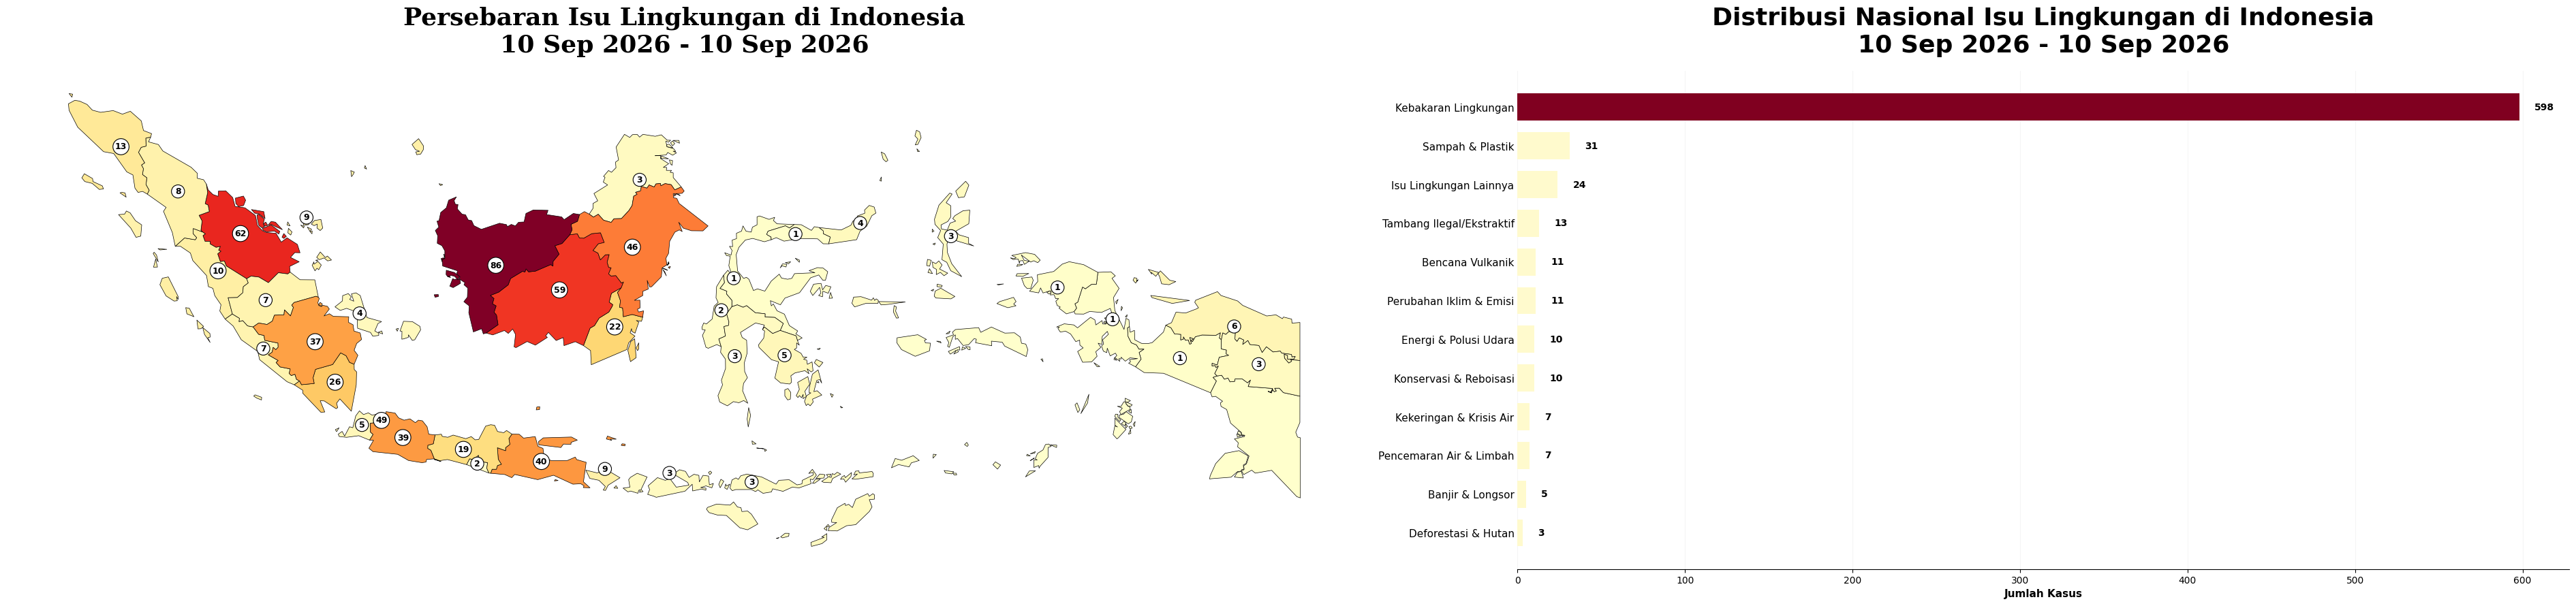

In [193]:
# =========================================================
# IMPORT LIBRARY
# =========================================================
import os
import re
import html
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import MultiPolygon
from tqdm.auto import tqdm
tqdm.pandas()


# =========================================================
# KONFIGURASI VISUALISASI
# =========================================================
CMAP_NAME = "YlOrRd"
TITLE_SIZE = 26

GEOJSON_PATH = "indonesia_38_provinsi.geojson"
GEOJSON_URL = (
    "https://raw.githubusercontent.com/denyherianto/"
    "indonesia-geojson-topojson-maps-with-38-provinces/main/"
    "GeoJSON/indonesia-38-provinces.geojson"
)
EXPECTED_PROVINCE_COUNT = 38

MANUAL_BADGE_POSITION = {
    "KEPULAUAN RIAU": (104.05, 1.30),
    "BALI": (115.15, -8.05),
    "NUSA TENGGARA BARAT": (117.55, -8.20),
}


# =========================================================
# HELPER: NORMALISASI NAMA PROVINSI
# =========================================================
PROVINCE_MAPPING = {
    "JAKARTA": "DKI JAKARTA",
    "DKI JAKARTA": "DKI JAKARTA",
    "YOGYAKARTA": "DI YOGYAKARTA",
    "DIY": "DI YOGYAKARTA",
    "DAERAH ISTIMEWA YOGYAKARTA": "DI YOGYAKARTA",
    "DI YOGYAKARTA": "DI YOGYAKARTA",
    "KEPULAUAN BANGKA BELITUNG": "BANGKA BELITUNG",
    "BANGKA BELITUNG": "BANGKA BELITUNG",
    "KEPRI": "KEPULAUAN RIAU",
    "KEPULAUAN RIAU": "KEPULAUAN RIAU",
    "PAPUA": "PAPUA",
    "PAPUA BARAT": "PAPUA BARAT",
    "PAPUA SELATAN": "PAPUA SELATAN",
    "PAPUA TENGAH": "PAPUA TENGAH",
    "PAPUA PEGUNUNGAN": "PAPUA PEGUNUNGAN",
    "PAPUA BARAT DAYA": "PAPUA BARAT DAYA",
    "NTB": "NUSA TENGGARA BARAT",
    "NUSA TENGGARA BARAT": "NUSA TENGGARA BARAT",
    "NTT": "NUSA TENGGARA TIMUR",
    "NUSA TENGGARA TIMUR": "NUSA TENGGARA TIMUR",
}

def _normalize_name(name: str) -> str:
    name = " ".join(str(name).strip().upper().split())
    return PROVINCE_MAPPING.get(name, name)

def _detect_province_column(map_gdf: gpd.GeoDataFrame):
    possible_columns = [
        "Provinsi", "Propinsi", "PROVINSI", "PROPINSI",
        "NAME_1", "WADMPR", "provinsi", "name", "NAME",
    ]
    for column in possible_columns:
        if column in map_gdf.columns:
            return column
    return None


# =========================================================
# HELPER: DOWNLOAD / LOAD GEOJSON
# =========================================================
def _load_geojson() -> gpd.GeoDataFrame:
    def _download():
        try:
            response = requests.get(GEOJSON_URL, timeout=30)
            response.raise_for_status()
            with open(GEOJSON_PATH, "wb") as file:
                file.write(response.content)
            return True
        except Exception as error:
            print("[ERROR] Gagal download GeoJSON:", error)
            return False

    if not os.path.exists(GEOJSON_PATH):
        if not _download():
            return gpd.GeoDataFrame()

    try:
        map_gdf = gpd.read_file(GEOJSON_PATH)
    except Exception as error:
        print("[ERROR] Gagal membaca GeoJSON:", error)
        return gpd.GeoDataFrame()

    if len(map_gdf) != EXPECTED_PROVINCE_COUNT:
        os.remove(GEOJSON_PATH)
        if not _download():
            return gpd.GeoDataFrame()
        try:
            map_gdf = gpd.read_file(GEOJSON_PATH)
        except Exception as error:
            print("[ERROR] Gagal membaca GeoJSON setelah redownload:", error)
            return gpd.GeoDataFrame()

    return map_gdf


# =========================================================
# HELPER: AGREGASI JUMLAH KASUS
# =========================================================
def _get_aggs(data: pd.DataFrame) -> pd.DataFrame:
    if "Provinsi" not in data.columns:
        print("[ERROR] Kolom 'Provinsi' tidak ditemukan pada dataset.")
        return pd.DataFrame(columns=["Provinsi", "jumlah_kasus", "provinsi_normalized"])

    aggs = data.groupby("Provinsi").size().reset_index(name="jumlah_kasus")
    aggs["provinsi_normalized"] = aggs["Provinsi"].apply(_normalize_name)
    return aggs


# =========================================================
# HELPER: MENYIAPKAN GEODATAFRAME (peta + jumlah kasus)
# =========================================================
def _get_map_gdf(data: pd.DataFrame) -> gpd.GeoDataFrame:
    map_gdf = _load_geojson()
    if map_gdf.empty:
        print("[ERROR] GeoJSON kosong.")
        return gpd.GeoDataFrame()

    prov_col = _detect_province_column(map_gdf)
    if prov_col is None:
        print("[ERROR] Kolom nama provinsi tidak ditemukan pada GeoJSON.")
        return gpd.GeoDataFrame()

    map_gdf["provinsi_normalized"] = map_gdf[prov_col].apply(_normalize_name)
    aggs = _get_aggs(data)

    map_gdf = map_gdf.merge(
        aggs[["provinsi_normalized", "jumlah_kasus"]],
        on="provinsi_normalized",
        how="left",
    )
    map_gdf["jumlah_kasus"] = map_gdf["jumlah_kasus"].fillna(0)

    return map_gdf


# =========================================================
# HELPER: TITIK UTAMA PROVINSI (anti-nyasar ke pulau kecil terpencil)
# =========================================================
def _main_point(geometry):
    if isinstance(geometry, MultiPolygon):
        largest_polygon = max(geometry.geoms, key=lambda geom: geom.area)
        return largest_polygon.representative_point()
    return geometry.representative_point()


# =========================================================
# PREPARE DATA: normalisasi Date, Sentiment, dan tentukan periode
# =========================================================
def prepare_data(data: pd.DataFrame):
    data = data.copy()

    data['Date'] = pd.to_datetime(data['Date'], format='ISO8601', errors='coerce').dt.normalize()

    if 'Sentiment' in data.columns:
        data['Sentiment'] = data['Sentiment'].astype(str).str.strip().str.lower()

    data = data.sort_values('Date', ascending=True, na_position='last').reset_index(drop=True)

    valid_dates = data['Date'].dropna()
    if valid_dates.empty:
        start_date = end_date = "Periode tidak diketahui"
    else:
        start_date = valid_dates.iloc[0].strftime('%d %b %Y')
        end_date = valid_dates.iloc[-1].strftime('%d %b %Y')

    return data, start_date, end_date


# =========================================================
# VISUAL GABUNGAN: PETA + BAR CHART (1 FIGURE, MENYAMPING)
# =========================================================
def plot_combined(data: pd.DataFrame, start_date, end_date):
    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(38, 9),
        gridspec_kw={"width_ratios": [1.3, 1]}
    )

    # --- SUBPLOT 1 (KIRI): PETA CHOROPLETH INDONESIA ---
    map_gdf = _get_map_gdf(data)
    if map_gdf.empty:
        print("[WARNING] Peta tidak dapat dirender.")
    else:
        prov_col = _detect_province_column(map_gdf)
        if prov_col is None:
            print("[ERROR] Kolom provinsi tidak ditemukan.")
        else:
            map_gdf.plot(
                column="jumlah_kasus", cmap=CMAP_NAME, linewidth=0.5, edgecolor="black",
                ax=ax1, legend=False,
                missing_kwds={"color": "#ffffe0", "edgecolor": "black", "linewidth": 0.5},
            )

            def _draw_badge(x, y, value):
                ax1.text(
                    x, y, f"{int(value)}", ha="center", va="center", zorder=10,
                    fontsize=9, fontweight="bold", color="black",
                    bbox=dict(boxstyle="circle,pad=0.25", facecolor="white", edgecolor="black", linewidth=0.8),
                )

            for _, row in map_gdf.iterrows():
                value = row["jumlah_kasus"]
                if value <= 0:
                    continue

                province = _normalize_name(row[prov_col])

                if province in MANUAL_BADGE_POSITION:
                    x, y = MANUAL_BADGE_POSITION[province]
                else:
                    point = _main_point(row.geometry)
                    x, y = point.x, point.y

                _draw_badge(x, y, value)

            ax1.set_title(
                f"Persebaran Isu Lingkungan di Indonesia\n{_format_period(start_date, end_date)}",
                fontsize=TITLE_SIZE, fontweight="bold", family="serif", pad=20,
            )
            ax1.axis("off")

    # --- SUBPLOT 2 (KANAN): BAR CHART DISTRIBUSI ISU NASIONAL ---
    if "Isu_Inti" not in data.columns:
        print("[ERROR] Kolom 'Isu_Inti' tidak ditemukan.")
    else:
        counts = data["Isu_Inti"].value_counts().sort_values(ascending=True)
        colors = (["#FFFACD"] * (len(counts) - 1) + ["#800020"]) if len(counts) > 1 else ["#800020"]
        bars = ax2.barh(counts.index, counts.values, color=colors, height=0.7)

        ax2.set_title(
            f"Distribusi Nasional Isu Lingkungan di Indonesia\n{_format_period(start_date, end_date)}",
            fontsize=TITLE_SIZE, fontweight="bold", pad=20,
        )
        ax2.set_xlabel("Jumlah Kasus", fontsize=11, fontweight="bold")
        ax2.tick_params(axis="y", labelsize=11, length=0)
        ax2.spines[["top", "right", "left"]].set_visible(False)
        ax2.xaxis.grid(True, linestyle="-", alpha=0.3, color="#e0e0e0")
        ax2.set_axisbelow(True)

        max_value = counts.max()
        for bar in bars:
            width = bar.get_width()
            ax2.text(
                width + max_value * 0.015, bar.get_y() + bar.get_height() / 2,
                f"{int(width)}", va="center", ha="left", fontsize=10, fontweight="bold",
            )

    plt.tight_layout()
    plt.show()
    return fig


def _format_period(start, end):
    return f"{start} - {end}"


df_clean, start_date, end_date = prepare_data(df_clean)
fig_combined = plot_combined(df_clean, start_date, end_date)

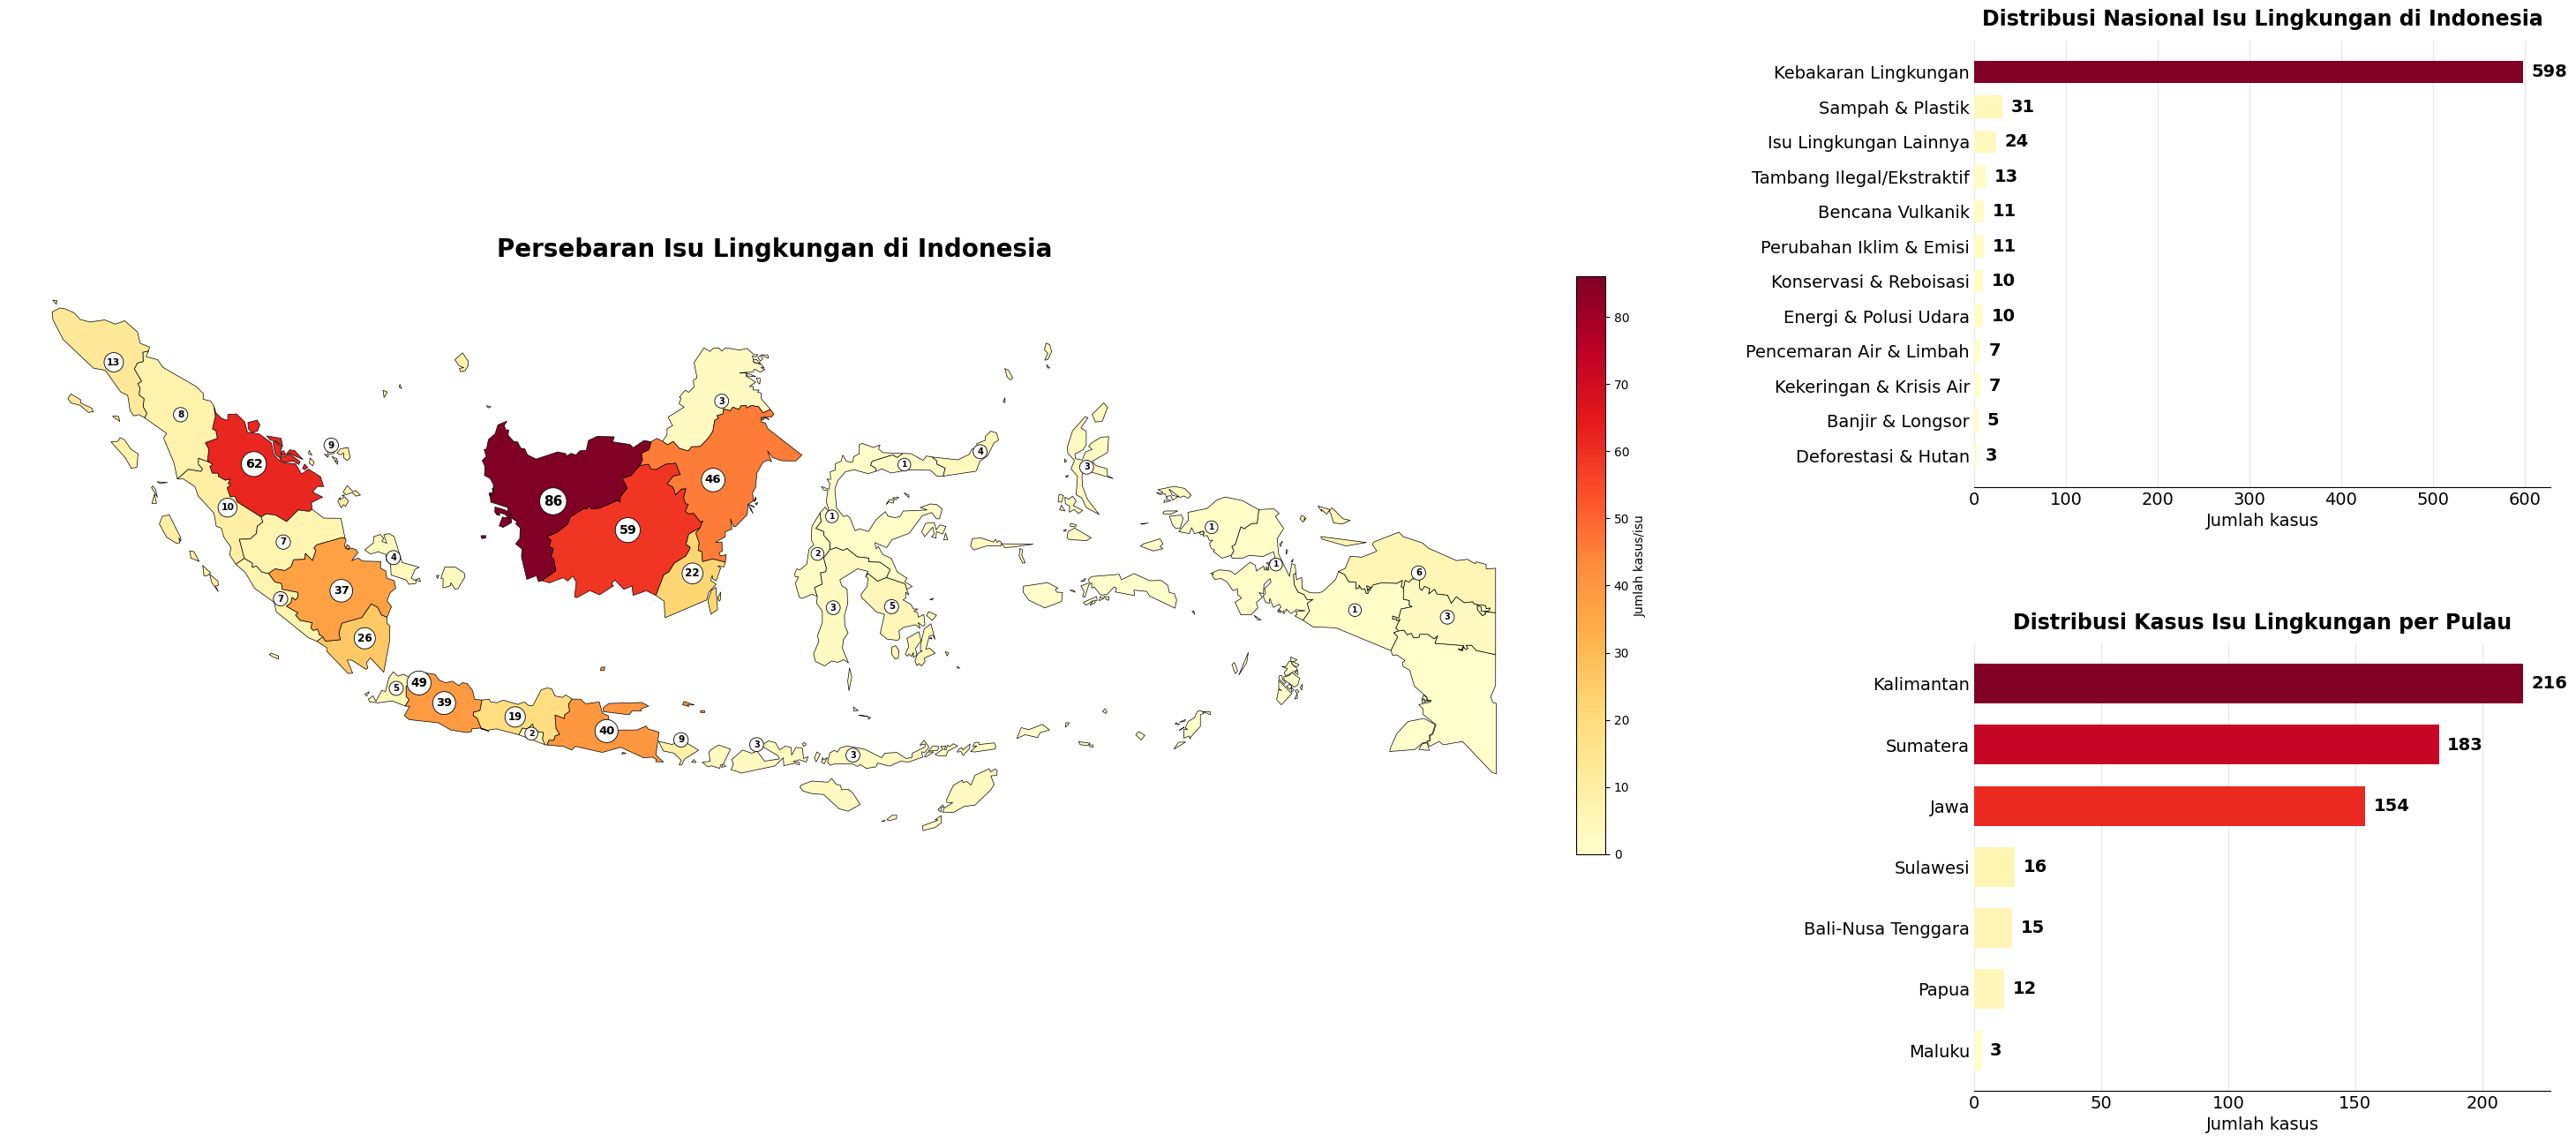

In [194]:
# =========================================================
# IMPORT LIBRARY
# =========================================================
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import MultiPolygon


# =========================================================
# KONFIGURASI VISUALISASI
# =========================================================
CMAP_NAME = "YlOrRd"

GEOJSON_PATH = "indonesia_38_provinsi.geojson"
GEOJSON_URL = (
    "https://raw.githubusercontent.com/denyherianto/"
    "indonesia-geojson-topojson-maps-with-38-provinces/main/"
    "GeoJSON/indonesia-38-provinces.geojson"
)
EXPECTED_PROVINCE_COUNT = 38

MANUAL_BADGE_POSITION = {
    "KEPULAUAN RIAU": (104.05, 1.30),
    "BALI": (115.15, -8.05),
    "NUSA TENGGARA BARAT": (117.55, -8.20),
}


# =========================================================
# HELPER: NORMALISASI NAMA PROVINSI
# =========================================================
PROVINCE_MAPPING = {
    "JAKARTA": "DKI JAKARTA",
    "DKI JAKARTA": "DKI JAKARTA",
    "YOGYAKARTA": "DI YOGYAKARTA",
    "DIY": "DI YOGYAKARTA",
    "DAERAH ISTIMEWA YOGYAKARTA": "DI YOGYAKARTA",
    "DI YOGYAKARTA": "DI YOGYAKARTA",
    "KEPULAUAN BANGKA BELITUNG": "BANGKA BELITUNG",
    "BANGKA BELITUNG": "BANGKA BELITUNG",
    "KEPRI": "KEPULAUAN RIAU",
    "KEPULAUAN RIAU": "KEPULAUAN RIAU",
    "PAPUA": "PAPUA",
    "PAPUA BARAT": "PAPUA BARAT",
    "PAPUA SELATAN": "PAPUA SELATAN",
    "PAPUA TENGAH": "PAPUA TENGAH",
    "PAPUA PEGUNUNGAN": "PAPUA PEGUNUNGAN",
    "PAPUA BARAT DAYA": "PAPUA BARAT DAYA",
    "NTB": "NUSA TENGGARA BARAT",
    "NUSA TENGGARA BARAT": "NUSA TENGGARA BARAT",
    "NTT": "NUSA TENGGARA TIMUR",
    "NUSA TENGGARA TIMUR": "NUSA TENGGARA TIMUR",
}

def _normalize_name(name: str) -> str:
    name = " ".join(str(name).strip().upper().split())
    return PROVINCE_MAPPING.get(name, name)

def _detect_province_column(map_gdf: gpd.GeoDataFrame):
    possible_columns = [
        "Provinsi", "Propinsi", "PROVINSI", "PROPINSI",
        "NAME_1", "WADMPR", "provinsi", "name", "NAME",
    ]
    for column in possible_columns:
        if column in map_gdf.columns:
            return column
    return None


# =========================================================
# HELPER: PROVINSI -> PULAU
# =========================================================
PROVINCE_TO_ISLAND = {
    "ACEH": "Sumatera", "SUMATERA UTARA": "Sumatera", "SUMATERA BARAT": "Sumatera",
    "RIAU": "Sumatera", "KEPULAUAN RIAU": "Sumatera", "JAMBI": "Sumatera",
    "SUMATERA SELATAN": "Sumatera", "BANGKA BELITUNG": "Sumatera",
    "BENGKULU": "Sumatera", "LAMPUNG": "Sumatera",

    "DKI JAKARTA": "Jawa", "JAWA BARAT": "Jawa", "JAWA TENGAH": "Jawa",
    "DI YOGYAKARTA": "Jawa", "JAWA TIMUR": "Jawa", "BANTEN": "Jawa",

    "KALIMANTAN BARAT": "Kalimantan", "KALIMANTAN TENGAH": "Kalimantan",
    "KALIMANTAN SELATAN": "Kalimantan", "KALIMANTAN TIMUR": "Kalimantan",
    "KALIMANTAN UTARA": "Kalimantan",

    "SULAWESI UTARA": "Sulawesi", "SULAWESI TENGAH": "Sulawesi",
    "SULAWESI SELATAN": "Sulawesi", "SULAWESI TENGGARA": "Sulawesi",
    "GORONTALO": "Sulawesi", "SULAWESI BARAT": "Sulawesi",

    "BALI": "Bali-Nusa Tenggara", "NUSA TENGGARA BARAT": "Bali-Nusa Tenggara",
    "NUSA TENGGARA TIMUR": "Bali-Nusa Tenggara",

    "MALUKU": "Maluku", "MALUKU UTARA": "Maluku",

    "PAPUA": "Papua", "PAPUA BARAT": "Papua", "PAPUA SELATAN": "Papua",
    "PAPUA TENGAH": "Papua", "PAPUA PEGUNUNGAN": "Papua", "PAPUA BARAT DAYA": "Papua",
}

def _get_island_aggs(data: pd.DataFrame) -> pd.Series:
    provinces = data["Provinsi"].apply(_normalize_name)
    islands = provinces.map(PROVINCE_TO_ISLAND)
    return islands.value_counts().sort_values(ascending=True)


# =========================================================
# HELPER: DOWNLOAD / LOAD GEOJSON
# =========================================================
def _load_geojson() -> gpd.GeoDataFrame:
    def _download():
        try:
            response = requests.get(GEOJSON_URL, timeout=30)
            response.raise_for_status()
            with open(GEOJSON_PATH, "wb") as file:
                file.write(response.content)
            return True
        except Exception as error:
            print("[ERROR] Gagal download GeoJSON:", error)
            return False

    if not os.path.exists(GEOJSON_PATH):
        if not _download():
            return gpd.GeoDataFrame()

    try:
        map_gdf = gpd.read_file(GEOJSON_PATH)
    except Exception as error:
        print("[ERROR] Gagal membaca GeoJSON:", error)
        return gpd.GeoDataFrame()

    if len(map_gdf) != EXPECTED_PROVINCE_COUNT:
        os.remove(GEOJSON_PATH)
        if not _download():
            return gpd.GeoDataFrame()
        try:
            map_gdf = gpd.read_file(GEOJSON_PATH)
        except Exception as error:
            print("[ERROR] Gagal membaca GeoJSON setelah redownload:", error)
            return gpd.GeoDataFrame()

    return map_gdf


# =========================================================
# HELPER: AGREGASI JUMLAH KASUS
# =========================================================
def _get_aggs(data: pd.DataFrame) -> pd.DataFrame:
    if "Provinsi" not in data.columns:
        print("[ERROR] Kolom 'Provinsi' tidak ditemukan pada dataset.")
        return pd.DataFrame(columns=["Provinsi", "jumlah_kasus", "provinsi_normalized"])

    aggs = data.groupby("Provinsi").size().reset_index(name="jumlah_kasus")
    aggs["provinsi_normalized"] = aggs["Provinsi"].apply(_normalize_name)
    return aggs


# =========================================================
# HELPER: MENYIAPKAN GEODATAFRAME (peta + jumlah kasus)
# =========================================================
def _get_map_gdf(data: pd.DataFrame) -> gpd.GeoDataFrame:
    map_gdf = _load_geojson()
    if map_gdf.empty:
        print("[ERROR] GeoJSON kosong.")
        return gpd.GeoDataFrame()

    prov_col = _detect_province_column(map_gdf)
    if prov_col is None:
        print("[ERROR] Kolom nama provinsi tidak ditemukan pada GeoJSON.")
        return gpd.GeoDataFrame()

    map_gdf["provinsi_normalized"] = map_gdf[prov_col].apply(_normalize_name)
    aggs = _get_aggs(data)

    map_gdf = map_gdf.merge(
        aggs[["provinsi_normalized", "jumlah_kasus"]],
        on="provinsi_normalized",
        how="left",
    )
    map_gdf["jumlah_kasus"] = map_gdf["jumlah_kasus"].fillna(0)

    return map_gdf


# =========================================================
# HELPER: TITIK UTAMA PROVINSI
# =========================================================
def _main_point(geometry):
    if isinstance(geometry, MultiPolygon):
        largest_polygon = max(geometry.geoms, key=lambda geom: geom.area)
        return largest_polygon.representative_point()
    return geometry.representative_point()


# =========================================================
# VISUAL GABUNGAN: HEADER + PETA (COLORBAR) + 2 BAR CHART
# =========================================================
def plot_dashboard(data: pd.DataFrame, start_date, end_date, report_date: str = None):
    fig = plt.figure(figsize=(30, 14))
    gs = fig.add_gridspec(2, 2, width_ratios=[3.2, 1], height_ratios=[1, 1], hspace=0.35, wspace=0.1)

    ax_map = fig.add_subplot(gs[:, 0])
    ax_nasional = fig.add_subplot(gs[0, 1])
    ax_pulau = fig.add_subplot(gs[1, 1])

    # --- PETA (dengan colorbar, badge proporsional) ---
    map_gdf = _get_map_gdf(data)
    if map_gdf.empty:
        print("[WARNING] Peta tidak dapat dirender.")
    else:
        prov_col = _detect_province_column(map_gdf)

        map_gdf.plot(
            column="jumlah_kasus", cmap=CMAP_NAME, linewidth=0.5, edgecolor="black",
            ax=ax_map, legend=True,
            legend_kwds={"label": "Jumlah kasus/isu", "shrink": 0.55, "pad": 0.02},
            missing_kwds={"color": "#d9d9d9", "edgecolor": "black", "linewidth": 0.5},
        )

        minx, miny, maxx, maxy = map_gdf.total_bounds
        pad_x, pad_y = (maxx - minx) * 0.03, (maxy - miny) * 0.05
        ax_map.set_xlim(minx - pad_x, maxx + pad_x)
        ax_map.set_ylim(miny - pad_y, maxy + pad_y)
        ax_map.set_aspect("equal")

        max_value = map_gdf["jumlah_kasus"].max() or 1

        for _, row in map_gdf.iterrows():
            value = row["jumlah_kasus"]
            if value <= 0:
                continue

            province = _normalize_name(row[prov_col])
            if province in MANUAL_BADGE_POSITION:
                x, y = MANUAL_BADGE_POSITION[province]
            else:
                point = _main_point(row.geometry)
                x, y = point.x, point.y

            scale = (value / max_value) ** 0.5
            font_size = 6 + scale * 5

            ax_map.text(
                x, y, f"{int(value)}", ha="center", va="center", zorder=10,
                fontsize=font_size, fontweight="bold", color="black",
                bbox=dict(boxstyle="circle,pad=0.3", facecolor="white",
                          edgecolor="black", linewidth=0.6),
            )

        ax_map.set_title("Persebaran Isu Lingkungan di Indonesia", fontsize=20, fontweight="bold", pad=14)
        ax_map.axis("off")

    # --- BAR CHART NASIONAL ---
    if "Isu_Inti" in data.columns:
        counts = data["Isu_Inti"].value_counts().sort_values(ascending=True)
        colors = plt.colormaps[CMAP_NAME]([v / counts.max() for v in counts.values])
        bars = ax_nasional.barh(counts.index, counts.values, color=colors, height=0.65)
        ax_nasional.set_title("Distribusi Nasional Isu Lingkungan di Indonesia", fontsize=17, fontweight="bold", pad=12)
        ax_nasional.set_xlabel("Jumlah kasus", fontsize=14)
        ax_nasional.tick_params(labelsize=14, length=0)
        ax_nasional.spines[["top", "right", "left"]].set_visible(False)
        ax_nasional.xaxis.grid(True, alpha=0.3)
        ax_nasional.set_axisbelow(True)
        max_value_n = counts.max()
        for bar in bars:
            width = bar.get_width()
            ax_nasional.text(width + max_value_n * 0.015, bar.get_y() + bar.get_height() / 2,
                              f"{int(width)}", va="center", fontsize=14, fontweight="bold")

    # --- BAR CHART PER PULAU ---
    if "Provinsi" in data.columns:
        island_counts = _get_island_aggs(data)
        colors_pulau = plt.colormaps[CMAP_NAME]([v / island_counts.max() for v in island_counts.values])
        bars2 = ax_pulau.barh(island_counts.index, island_counts.values, color=colors_pulau, height=0.65)
        ax_pulau.set_title("Distribusi Kasus Isu Lingkungan per Pulau", fontsize=17, fontweight="bold", pad=12)
        ax_pulau.set_xlabel("Jumlah kasus", fontsize=14)
        ax_pulau.tick_params(labelsize=14, length=0)
        ax_pulau.spines[["top", "right", "left"]].set_visible(False)
        ax_pulau.xaxis.grid(True, alpha=0.3)
        ax_pulau.set_axisbelow(True)
        max_value2 = island_counts.max()
        for bar in bars2:
            width = bar.get_width()
            ax_pulau.text(width + max_value2 * 0.015, bar.get_y() + bar.get_height() / 2,
                           f"{int(width)}", va="center", fontsize=14, fontweight="bold")


    plt.subplots_adjust(left=0.02, right=0.98, top=0.9, bottom=0.05)
    plt.show()
    return fig

df_clean, start_date, end_date = prepare_data(df_clean)
fig_dashboard = plot_dashboard(df_clean, start_date, end_date, report_date="09 September 2026")

In [195]:
# =========================================================
# OUTPUT BERITA: 5 pulau teratas -> 2 isu terame per pulau -> link
# =========================================================
df_berita = df_clean[df_clean["Tipe_Link"] == "Berita"]

top5_pulau = (
    df_berita[~df_berita["Pulau"].isin(["Tidak Terdeteksi"])]
    .groupby("Pulau")
    .size()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

berita_rows = []
for pulau in top5_pulau:
    subset = df_berita[df_berita["Pulau"] == pulau]
    top2_isu = subset["Isu_Inti"].value_counts().head(2)

    for isu, jumlah_isu in top2_isu.items():
        links = subset[subset["Isu_Inti"] == isu]["Link"].head(5).tolist()
        for link in links:
            berita_rows.append({
                "Pulau": pulau,
                "Isu": isu,
                "Jumlah Berita (Isu)": jumlah_isu,
                "Link": link,
            })

berita_table = pd.DataFrame(berita_rows)
print("BERITA — 5 PULAU TERATAS, 2 ISU TERAME PER PULAU:")
display(berita_table)


# =========================================================
# OUTPUT MEDIA SOSIAL: 5 isu terame
# =========================================================
df_medsos = df_clean[df_clean["Tipe_Link"] == "Media Sosial"]

top5_isu_medsos = df_medsos["Isu_Inti"].value_counts().head(5)

medsos_rows = []
for isu, jumlah_isu in top5_isu_medsos.items():
    links = df_medsos[df_medsos["Isu_Inti"] == isu]["Link"].head(5).tolist()
    for link in links:
        medsos_rows.append({
            "Isu": isu,
            "Jumlah Postingan (Isu)": jumlah_isu,
            "Link": link,
        })

medsos_table = pd.DataFrame(medsos_rows)
print("\nMEDIA SOSIAL — 5 ISU TERAME:")
display(medsos_table)

BERITA — 5 PULAU TERATAS, 2 ISU TERAME PER PULAU:


,Pulau,Isu,Jumlah Berita (Isu),Link
0,Kalimantan,Kebakaran Lingkungan,157,https://www.cnnindonesia.com/nasional/20260910132655-22-1402367/foto-karhutla-masih-membara-di-palangka-raya
1,Kalimantan,Kebakaran Lingkungan,157,https://www.detik.com/kalimantan/berita/d-8656823/titik-api-berkurang-status-tanggap-darurat-asap-di-kalbar-masih-diperpanjang
2,Kalimantan,Kebakaran Lingkungan,157,https://timesindonesia.co.id/peristiwa-daerah/607905/wapres-gibran-diadang-warga-adukan-rumah-terbakar-akibat-karhutla
3,Kalimantan,Kebakaran Lingkungan,157,https://regional.kompas.com/read/2026/09/10/142318978/kapal-perang-jepang-tiba-di-kalbar-bawa-3-helikopter-chinook-untuk-tangani
4,Kalimantan,Kebakaran Lingkungan,157,https://www.metrotvnews.com/read/Ky6C5X1g-bpbd-kalbar-inventarisasi-kebutuhan-warga-terdampak-karhutla-dan-kekeringan
5,Kalimantan,Sampah & Plastik,3,https://poroskalimantan.com/balangan-hasilkan-595-ton-sampah-per-hari-sampai-organik-mendominasi/
6,Kalimantan,Sampah & Plastik,3,https://kaltim.antaranews.com/berita/266652/dlh-kota-balikpapan-perkuat-strategi-pengelolaan-sampah
7,Kalimantan,Sampah & Plastik,3,https://lintasjatimnews.com/2026/09/09/pemerintah-pusat-dorong-pemda-kalsel-amankan-aset-daerah-untuk-keberlanjutan-program-pengolahan-sampah/
8,Sumatera,Kebakaran Lingkungan,132,https://www.cnnindonesia.com/nasional/20260910123941-22-1402340/foto-karhutla-di-tahura-jambi-meluas-hingga-30-hektare
9,Sumatera,Kebakaran Lingkungan,132,https://regional.kompas.com/read/2026/09/10/142647378/kabut-asap-memburuk-disdik-sumsel-izinkan-sekolah-terapkan-pjj



MEDIA SOSIAL — 5 ISU TERAME:


,Isu,Jumlah Postingan (Isu),Link
0,Kebakaran Lingkungan,198,https://www.instagram.com/p/DdGKqwgv5qS
1,Kebakaran Lingkungan,198,https://www.tiktok.com/@ren_resmuna/photo/7683769128091438356
2,Kebakaran Lingkungan,198,https://www.instagram.com/p/DdGFRW2EfZJ
3,Kebakaran Lingkungan,198,https://www.youtube.com/watch?v=_l66AE3bxDo
4,Kebakaran Lingkungan,198,https://www.youtube.com/watch?v=hfV9plhMh4c
5,Isu Lingkungan Lainnya,11,https://www.facebook.com/bangkapos/posts/pfbid02K6o8h9cqen5186AHS4iJAxwM245uzjrSALSqBXuy633PCcAnjcSHNAKW14EMHfvAl
6,Isu Lingkungan Lainnya,11,https://twitter.com/web/statuses/2097912199042011595
7,Isu Lingkungan Lainnya,11,https://www.youtube.com/watch?v=CGqak98-oAw
8,Isu Lingkungan Lainnya,11,https://www.tiktok.com/@setwapres.ri/video/7683737657293196564
9,Isu Lingkungan Lainnya,11,https://www.instagram.com/p/DdFy2gjSgZd


trash

In [196]:
from collections import Counter
import re

STOPWORDS_ID = set("""
yang di ke dari dan atau untuk pada dengan dalam ini itu adalah akan telah
sudah tidak juga karena oleh sebagai atas dapat bisa saat ketika para
antara namun tetapi jika kata ada tahun hari lalu kemarin sebut ujar
kata dia mereka kami kita saya anda tersebut baik serta hingga sekitar
lebih dua satu tiga bagi setelah sejak selama menjadi terkait
""".split())

def top_terms(texts, n=40, ngram=1):
    counter = Counter()
    for t in texts:
        words = re.findall(r'\b[a-z]{3,}\b', str(t).lower())
        words = [w for w in words if w not in STOPWORDS_ID]
        if ngram == 1:
            counter.update(words)
        else:
            grams = zip(*[words[i:] for i in range(ngram)])
            counter.update(" ".join(g) for g in grams)
    return counter.most_common(n)

# --- 1) Kata & frasa tersering di dokumen "Isu Lingkungan Lainnya" ---
unclassified = df_clean.loc[df_clean["Isu_Inti"] == "Isu Lingkungan Lainnya", "search_text"]
print(f"Jumlah dokumen belum terklasifikasi: {len(unclassified)}\n")
print("Top kata:")
for w, c in top_terms(unclassified, n=40, ngram=1):
    print(f"  {w}: {c}")
print("\nTop frasa 2 kata:")
for p, c in top_terms(unclassified, n=30, ngram=2):
    print(f"  {p}: {c}")

# Baca beberapa headline mentahnya langsung
display(df_clean.loc[df_clean["Isu_Inti"] == "Isu Lingkungan Lainnya", ["doc_id", "Mentions"]].sample(20, random_state=42))

# --- 2) Kata & frasa tersering di dokumen yang lokasinya "Tidak Terdeteksi" ---
no_loc = df_clean.loc[df_clean["Provinsi"] == "Tidak Terdeteksi", "search_text"]
print(f"\nJumlah dokumen tanpa lokasi: {len(no_loc)}\n")
print("Top kata:")
for w, c in top_terms(no_loc, n=40, ngram=1):
    print(f"  {w}: {c}")
print("\nTop frasa 2 kata:")
for p, c in top_terms(no_loc, n=30, ngram=2):
    print(f"  {p}: {c}")

display(df_clean.loc[df_clean["Provinsi"] == "Tidak Terdeteksi", ["doc_id", "Mentions"]].sample(20, random_state=42))

Jumlah dokumen belum terklasifikasi: 24

Top kata:
  indonesia: 29
  tim: 29
  lingkungan: 26
  kabupaten: 26
  cdm: 22
  atlet: 22
  todotua: 21
  tubuh: 21
  karya: 20
  kondisi: 19
  mahasiswa: 19
  trenggalek: 19
  nagoya: 18
  rumah: 17
  september: 16
  bekasi: 16
  petani: 16
  kembali: 15
  kawasan: 15
  banjir: 14
  terhadap: 14
  terus: 14
  melakukan: 14
  rabu: 13
  asian: 12
  games: 12
  jepang: 12
  wapres: 12
  wilayah: 12
  foto: 12
  berada: 11
  kegiatan: 11
  langkah: 11
  pemerintah: 11
  pasien: 11
  aman: 10
  memastikan: 10
  itb: 10
  inovasi: 10
  bersama: 10

Top frasa 2 kata:
  asian games: 12
  kabupaten bekasi: 11
  september foto: 11
  atlet indonesia: 9
  tim indonesia: 9
  todotua pasaribu: 8
  cdm todotua: 7
  games aichi: 7
  aichi nagoya: 7
  chef mission: 7
  mission cdm: 7
  mahasiswa itb: 7
  tim cdm: 7
  nagoya todotua: 7
  rumah sakit: 7
  banjir nagoya: 6
  cdm tim: 6
  ecology policing: 6
  ratusan tukik: 6
  kabupaten trenggalek: 6
  rantau k

,doc_id,Mentions
308,DOC-00423,"TRENGGALEK &ndash; Kapolres Trenggalek, AKBP Rizky Tri Putra Erryka Adi Wijaya, S.I.K., M.H., didampingi Ketua Cabang Bhayangkari Trenggalek, Ny. ..."
509,DOC-00725,Komisi III DPRD Kabupaten Bekasi menggelar audiensi dengan pihak PT Fajar Surya Wisesa Tbk (Fajar Paper) untuk membahas pembangunan fasilitas peng...
67,DOC-00099,"Banjir di Nagoya jelang Asian Games 2026, CdM Todotua menegaskan atlet Indonesia aman. Panitia siaga, basket 5on5 putra main 10 September vs Jepan..."
634,DOC-00935,Ikn kota percontohan dunia❤️
353,DOC-00490,"IPOL.ID-Chef de Mission (CdM) Tim Indonesia untuk Asian Games Aichi-Nagoya 2026, Todotua Pasaribu, memastikan seluruh atlet Indonesia yang telah b..."
309,DOC-00424,"TRENGGALEK &ndash; Kapolres Trenggalek, AKBP Rizky Tri Putra Erryka Adi Wijaya, S.I.K., M.H., didampingi Ketua Cabang Bhayangkari Trenggalek, Ny. ..."
392,DOC-00546,Mosok Sih Kita Adem Ayem Lihat Kayak Begini : Stop KORUPSI SEKARANG JUGA !. Fix ! IPK NKRI sekelas NEPAL/Siera Leon ; tahun 2026 : 34 ( setahun P...
140,DOC-00193,"Wapres Gibran Rakabuming (kiri) mendengarkan penjelasan terkait inovasi mahasiswa ITB dalam pertemuan di Istana Wakil Presiden, Jakarta, Rabu (9/9..."
684,DOC-01035,"RT AKSI #DEMO BEM IPB ""RIP Prabowo &amp; Gibran"" BEM KM IPB menyuarakan matinya harapan demokrasi lewat simbol kuburan ""RIP Prabowo &amp; Gibran""..."
284,DOC-00395,"Wapres Dorong Inovasi Mahasiswa ITB Berdampak Lebih Luas. Machine learning untuk sektor energi, sistem pemeliharaan alat berat, drone pemantau kua..."



Jumlah dokumen tanpa lokasi: 102

Top kata:
  kebakaran: 167
  hutan: 134
  karhutla: 119
  sampah: 87
  lahan: 82
  masyarakat: 69
  api: 59
  lingkungan: 56
  indonesia: 56
  haarp: 50
  energi: 45
  kondisi: 41
  pemerintah: 39
  masih: 37
  secara: 37
  rumah: 36
  bencana: 36
  negara: 35
  warga: 35
  harus: 34
  hujan: 34
  terjadi: 33
  asap: 32
  penanganan: 32
  hanya: 31
  petugas: 30
  berbagai: 30
  bukan: 30
  wilayah: 30
  september: 29
  melakukan: 29
  bagian: 29
  pembakaran: 29
  malaysia: 28
  tempat: 27
  jepang: 27
  dilakukan: 26
  terus: 25
  masalah: 24
  sejumlah: 24

Top frasa 2 kata:
  kebakaran hutan: 118
  hutan lahan: 39
  lahan karhutla: 31
  risiko kebakaran: 18
  hutan negara: 17
  pemadam kebakaran: 16
  negara bagian: 16
  kabut asap: 15
  bagian uffington: 15
  uffington dekat: 15
  dekat clarence: 15
  clarence town: 15
  town australia: 15
  sejumlah wilayah: 14
  australia september: 14
  hujan deras: 14
  petugas pemadam: 12
  membuang sampah: 

,doc_id,Mentions
356,DOC-00495,"KARHUTLA: Bencana Alam atau Bencana Kepentingan? | Muslimah&#39;s Mind. Karhutla terus berulang setiap tahun. Api masih berkobar, lingkungan rusak..."
584,DOC-00866,"Di balik lahan yang menghitam dan pepohonan yang hangus, ada kehidupan lain yang kehilangan tempat berlindung. Kebakaran hutan dan lahan dapat mer..."
555,DOC-00817,"@txtdrimedia Muak bgt sama kenaifan orang Indonesia, kelihatan di statement Kepala BNPB. Hutan dibakar buat apa? Ya buat lahan sawit lah. Dari tah..."
470,DOC-00671,RT Sawit tumbuh segar pasca kebakaran hutan Presiden @prabowo MURKA Mungkin mereka pikir oknum2 aparat bisa DISOGOK Presiden Prabowo MENGHARAMK...
448,DOC-00628,"*CEGAH KARHUTLA* Bhabinkamtibmas Wukirsari Aipda Chrismawan aksanakan siaga dan pantau wi cegah karhutla di Posko Pengkolan, Wukirsari, Imogiri, ..."
410,DOC-00606,Australia bersiap menghadapi musim kebakaran hutan akibat El Nino yang memicu cuaca panas dan kering.\n\nPetugas pemadam kebakaran musiman dari Fo...
651,DOC-00976,@andreas_ardetta Keracunan jangan dilaporkan presiden. Bilang aja kl tepung sudah mulai diproduksi untuk padamkan kebakaran hutan Betul ngak @BA...
464,DOC-00661,HEWAN TERJEBAK DI JARING! 😱🔥 PEMADAM BERJUANG MEMADAMKAN KEBAKARAN HUTAN | Cerita Mainan Anak. Seekor Hewan terjebak di dalam jaring dan membutuhk...
162,DOC-00228,Konten ini dibuat oleh pengguna Kompasiana. Seluruh isi menjadi tanggung jawab penulis dan tidak mewakili pandangan resmi redaksi Kompas.\n\nBahas...
1,DOC-00002,"RT maap kalau party pooper, tapi sumpah yah yang kemarin heboh koar2 soal krisis iklim dan kerusakan lingkungan, skrg malah pada latah generate fo..."
